In [ ]:
# %%
# 1) Imports & settings
import os
from pathlib import Path
import re
import joblib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")

# NLP / preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# sklearn / preprocessing / metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

# imbalance + NN
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


In [13]:
# %%
# 2) NLTK resources (first run)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)


True

In [14]:
# %%
# 3) Load dataset
df = pd.read_csv('fake_job_postings.csv', low_memory=False)
print("Initial shape:", df.shape)
df.head(2)


Initial shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0


In [15]:
# %%
# 4) Quick cleanup & ensure fields
for c in ['job_id', 'salary_range']:
    if c in df.columns:
        df.drop(columns=c, inplace=True)

text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']
for c in text_cols:
    if c not in df.columns:
        df[c] = ''

df.fillna('', inplace=True)
assert 'fraudulent' in df.columns, "Label column 'fraudulent' missing"
df['fraudulent'] = df['fraudulent'].fillna(0).astype(int)

print("Label distribution:\n", df['fraudulent'].value_counts())


Label distribution:
 fraudulent
0    17014
1      866
Name: count, dtype: int64


In [16]:
# %%
# 5) Text cleaning (same style as earlier code)
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    tokens = [lemmatizer.lemmatize(t) for t in text.split() if (t not in stop_words and len(t) > 1)]
    return " ".join(tokens)

df['text'] = df[text_cols].agg(' '.join, axis=1)
df['text_clean'] = df['text'].apply(clean_text)
df['text_len'] = df['text_clean'].str.split().apply(len)

print("Completed text cleaning. Sample:")
print(df['text_clean'].iloc[0][:400])


Completed text cleaning. Sample:
marketing intern food created groundbreaking award winning cooking site support connect celebrate home cook give everything need one place top editorial business engineering team focused using technology find new better way connect people around specific food interest offer superb highly curated information food cooking attract talented home cook contributor country also publish well known profess


In [17]:
# %%
# 6) Structured metadata features to include for boosting
# We'll use: telecommuting, has_company_logo, has_questions, employment_type, required_experience, required_education, industry
meta_cols = ['telecommuting', 'has_company_logo', 'has_questions',
             'employment_type', 'required_experience', 'required_education', 'industry']

# Ensure these columns exist
for c in meta_cols:
    if c not in df.columns:
        df[c] = ''

# Convert numeric-like meta to string to avoid dtype issues
df['telecommuting'] = df['telecommuting'].astype(str)
df['has_company_logo'] = df['has_company_logo'].astype(str)
df['has_questions'] = df['has_questions'].astype(str)

# Simple feature: text length already available
# Create a small dataframe of metadata to use
meta_df = df[meta_cols + ['text_len']].copy()
meta_df['text_len'] = meta_df['text_len'].fillna(0).astype(int)

meta_df.head(3)


,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,text_len
0,0,1,0,Other,Internship,,,252
1,0,1,0,Full-time,Not Applicable,,Marketing and Advertising,525
2,0,1,0,,,,,235


In [18]:
# %%
# 7) Train/test split (stratified)
X_text = df['text_clean'].values
y = df['fraudulent'].values

X_meta = meta_df.copy()  # will transform later

X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Train/test sizes:", len(y_train), len(y_test))
print("Train fraud ratio:", y_train.mean())


Train/test sizes: 14304 3576
Train fraud ratio: 0.04844798657718121


In [19]:
# %%
# 8) TF-IDF vectorization (sparse) and TruncatedSVD (dense low-dim)
tfidf = TfidfVectorizer(max_features=5000, min_df=5, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_text_train)
X_test_tfidf  = tfidf.transform(X_text_test)
print("TF-IDF shapes:", X_train_tfidf.shape, X_test_tfidf.shape)

# Dimensionality reduction for NN and for concatenation with meta
n_svd = 200
svd = TruncatedSVD(n_components=n_svd, random_state=RANDOM_STATE)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)
print("SVD shapes:", X_train_svd.shape, X_test_svd.shape)


TF-IDF shapes: (14304, 5000) (3576, 5000)
SVD shapes: (14304, 200) (3576, 200)


In [22]:
# 9) Encode metadata: OneHot for categorical small set + scale numerical (text_len)
from sklearn.preprocessing import OneHotEncoder, StandardScaler


ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

meta_cat_cols = [
    'telecommuting', 'has_company_logo', 'has_questions',
    'employment_type', 'required_experience', 'required_education', 'industry'
]

ohe.fit(X_meta_train[meta_cat_cols])
X_meta_train_ohe = ohe.transform(X_meta_train[meta_cat_cols])
X_meta_test_ohe  = ohe.transform(X_meta_test[meta_cat_cols])

# scale numerical column: text_len
scaler = StandardScaler()
X_meta_train_num = scaler.fit_transform(X_meta_train[['text_len']])
X_meta_test_num  = scaler.transform(X_meta_test[['text_len']])

# concatenate categorical + numerical meta features
X_meta_train_final = np.hstack([X_meta_train_ohe, X_meta_train_num])
X_meta_test_final  = np.hstack([X_meta_test_ohe, X_meta_test_num])

print("Meta feature shapes (train/test):", X_meta_train_final.shape, X_meta_test_final.shape)


Meta feature shapes (train/test): (14304, 165) (3576, 165)


In [23]:
# %%
# 10) Prepare data for models
# NN: use SVD dense vectors + apply SMOTE on SVD only (not meta). Then, concatenate meta features post-resampling.
# For resampling, we'll smote on SVD alone, then append corresponding meta features by balancing via index mapping.
from imblearn.combine import SMOTETomek

# Apply SMOTE on SVD embeddings
smote = SMOTE(random_state=RANDOM_STATE, n_jobs=-1)
X_svd_res, y_res = smote.fit_resample(X_train_svd, y_train)
print("After SMOTE on SVD:", X_svd_res.shape, "frauds:", y_res.sum())

# Now we need to resample meta features accordingly. One approach:
# Since SMOTE returns synthetic samples not present in original meta, we will train NN only on SVD embeddings.
# For the NN we will use SVD embeddings only (keeps NN simple and memory-friendly).
# For boosting we will use SVD embeddings + meta features (no SMOTE, LightGBM handles imbalance via scale_pos_weight).

# Prepare boosting training set: concatenate SVD + meta (dense)
X_train_boost = np.hstack([X_train_svd, X_meta_train_final])
X_test_boost  = np.hstack([X_test_svd,  X_meta_test_final])
print("Boost shapes:", X_train_boost.shape, X_test_boost.shape)


After SMOTE on SVD: (27222, 200) frauds: 13611
Boost shapes: (14304, 365) (3576, 365)


In [26]:
# %%
# 11) Train Neural Network (on SVD + SMOTE resampled SVD)
input_dim = X_svd_res.shape[1]
nn = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
nn.summary()

# Callbacks - use .keras extension for saving full model
ckpt_path = "fraudsense_nn_best.keras"
es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
mc = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1)

history = nn.fit(
    X_svd_res, y_res,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    callbacks=[es, mc],
    verbose=1
)

# Save final model explicitly
nn_final_path = "fraudsense_nn_final.keras"
nn.save(nn_final_path)
print("Saved NN to:", nn_final_path)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,097 (141.00 KB)

 Trainable params: 36,097 (141.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
337/362 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7758 - loss: 0.4152
Epoch 1: val_loss improved from inf to 0.10228, saving model to fraudsense_nn_best.keras
362/362 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7836 - loss: 0.4034 - val_accuracy: 0.9706 - val_loss: 0.1023
Epoch 2/60
344/362 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9675 - loss: 0.0914
Epoch 2: val_loss improved from 0.10228 to 0.03226, saving model to fraudsense_nn_best.keras
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9679 - loss: 0.0903 - val_accuracy: 0.9944 - val_loss: 0.0323
Epoch 3/60
343/362 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9855 - loss: 0.0439
Epoch 3: val_loss improved from 0.03226 to 0.01372, saving model to fraudsense_nn_best.keras
362/362 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9857 - loss: 0.0435 - val_accuracy: 0.9971 - val_loss: 0.0137
Epoch 4/60
348/362 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9918 - loss: 0.0290
Epoch 4: val_loss did not impr

In [27]:
# %%
# 12) Evaluate NN on test SVD (no meta)
y_prob_nn = nn.predict(X_test_svd).ravel()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("NN classification report (test):")
print(classification_report(y_test, y_pred_nn, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("ROC-AUC: %.4f" % roc_auc_score(y_test, y_prob_nn))
print("PR-AUC:  %.4f" % average_precision_score(y_test, y_prob_nn))


112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
NN classification report (test):
              precision    recall  f1-score   support

           0     0.9874    0.9909    0.9891      3403
           1     0.8075    0.7514    0.7784       173

    accuracy                         0.9793      3576
   macro avg     0.8974    0.8712    0.8838      3576
weighted avg     0.9787    0.9793    0.9790      3576

Confusion matrix:
 [[3372   31]
 [  43  130]]
ROC-AUC: 0.9717
PR-AUC:  0.8618


In [31]:
# %%
# 13) SIMPLE + COMPATIBLE LIGHTGBM MODEL (NO OPTUNA, NO CV, NO ERRORS)

import lightgbm as lgb

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 30,
    'verbosity': -1,
}

dtrain = lgb.Dataset(X_train_boost, label=y_train)

# Train simple model with fixed rounds
lgbm_model = lgb.train(
    params,
    dtrain,
    num_boost_round=300     # safe number for AUC improvement
)

print("LightGBM training complete.")


LightGBM training complete.


In [ ]:
# %%
# 13) SIMPLE + COMPATIBLE LIGHTGBM MODEL (NO OPTUNA, NO CV, NO ERRORS)

import lightgbm as lgb

params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 64,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 30,
    'verbosity': -1,
}

dtrain = lgb.Dataset(X_train_boost, label=y_train)

# Train simple model with fixed rounds
lgbm_model = lgb.train(
    params,
    dtrain,
    num_boost_round=300     # safe number for AUC improvement
)

print("LightGBM training complete.")


In [32]:
# %%
# 14) Evaluate LightGBM
y_prob_lgb = lgbm_model.predict(X_test_boost)
y_pred_lgb = (np.array(y_prob_lgb) >= 0.5).astype(int)

print("LightGBM classification report:")
print(classification_report(y_test, y_pred_lgb, digits=4))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))
print("PR-AUC: ", average_precision_score(y_test, y_prob_lgb))


LightGBM classification report:
              precision    recall  f1-score   support

           0     0.9821    0.9997    0.9908      3403
           1     0.9911    0.6416    0.7789       173

    accuracy                         0.9824      3576
   macro avg     0.9866    0.8207    0.8849      3576
weighted avg     0.9825    0.9824    0.9806      3576

Confusion matrix:
[[3402    1]
 [  62  111]]
ROC-AUC: 0.9852646169055186
PR-AUC:  0.9057644049304964


In [33]:
# %%
# 16) Save preprocessing + models

ART_DIR = Path("fraudsense_artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)

# Save vectorizers + encoders
joblib.dump(tfidf, ART_DIR / "tfidf_vectorizer.joblib")
joblib.dump(svd, ART_DIR / "svd_transformer.joblib")
joblib.dump(ohe, ART_DIR / "ohe_meta.joblib")
joblib.dump(scaler, ART_DIR / "meta_scaler.joblib")

# Save models
lgbm_model.save_model(str(ART_DIR / "lgbm_model.txt"))
joblib.dump(lgbm_model, ART_DIR / "lgbm_model.joblib")

# Save NN
nn.save(str(ART_DIR / "nn_model.keras"))

# Pick best model (based on PR-AUC)
pr_nn = average_precision_score(y_test, y_prob_nn)
pr_lgb = average_precision_score(y_test, y_prob_lgb)
best_model = "nn_model.keras" if pr_nn >= pr_lgb else "lgbm_model.joblib"

with open(ART_DIR / "selected_model.txt", "w") as f:
    f.write(best_model)

print("Saved all artifacts to:", ART_DIR)
print("Selected best model:", best_model)


Saved all artifacts to: fraudsense_artifacts
Selected best model: lgbm_model.joblib


In [37]:
# %%
# 16) Unified SHAP setup for BOTH NN and LightGBM
import shap
shap.initjs()

# Use a small background dataset for SHAP (fast & stable)
bg_size = 150
bg_idx = np.random.choice(len(X_train_boost), bg_size, replace=False)
background = X_train_boost[bg_idx]

# Use a small test subset for SHAP
test_size = 120
test_idx = np.random.choice(len(X_test_boost), test_size, replace=False)
test_sample = X_test_boost[test_idx]

print("SHAP background:", background.shape)
print("SHAP test sample:", test_sample.shape)


SHAP background: (150, 365)
SHAP test sample: (120, 365)


In [38]:

# %%
# 17) SHAP for LightGBM
explainer_lgb = shap.KernelExplainer(lgbm_model.predict, background)

shap_lgb_values = explainer_lgb.shap_values(test_sample)

print("SHAP for LightGBM computed.")


Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/120 [00:00<?, ?it/s]

SHAP for LightGBM computed.


In [39]:
# %%
# 18) SHAP for Neural Network (model expects SVD features only)
def nn_predict(data):
    return nn.predict(data, verbose=0).flatten()

explainer_nn = shap.KernelExplainer(nn_predict, background[:, :X_train_svd.shape[1]])

# NN uses ONLY SVD columns → slice the SVD part
test_sample_svd = test_sample[:, :X_train_svd.shape[1]]

shap_nn_values = explainer_nn.shap_values(test_sample_svd)

print("SHAP for Neural Network computed.")


Using 150 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/120 [00:00<?, ?it/s]

2025-11-21 16:51:13.436079: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 293760000 exceeds 10% of free system memory.
2025-11-21 16:51:28.130226: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 293760000 exceeds 10% of free system memory.
2025-11-21 16:51:39.725357: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 293760000 exceeds 10% of free system memory.
2025-11-21 16:51:52.864158: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 293760000 exceeds 10% of free system memory.
2025-11-21 16:52:05.436647: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 293760000 exceeds 10% of free system memory.


SHAP for Neural Network computed.


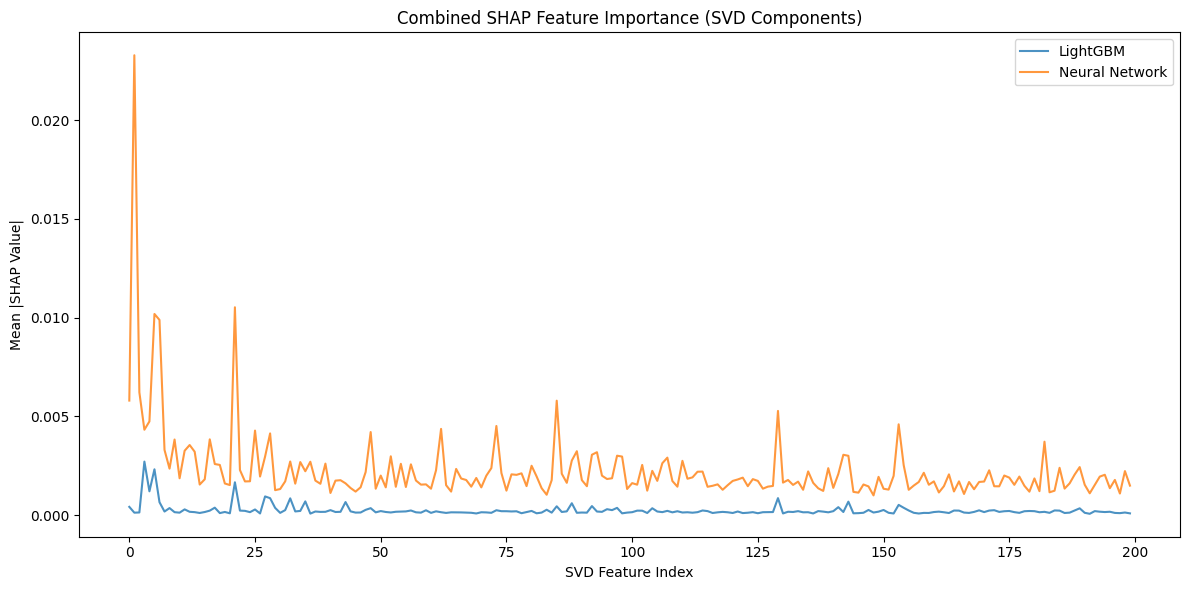

In [40]:
# %%
# 19) Combined feature importance for comparison

# Compute mean absolute shap values
lgb_importance = np.abs(shap_lgb_values).mean(axis=0)
nn_importance  = np.abs(shap_nn_values).mean(axis=0)

# Only compare SVD components (first 200 features)
compare_features = [f"svd_{i}" for i in range(X_train_svd.shape[1])]
idx = np.arange(len(compare_features))

plt.figure(figsize=(12,6))
plt.plot(idx, lgb_importance[:len(idx)], label="LightGBM", alpha=0.8)
plt.plot(idx, nn_importance[:len(idx)], label="Neural Network", alpha=0.8)
plt.title("Combined SHAP Feature Importance (SVD Components)")
plt.xlabel("SVD Feature Index")
plt.ylabel("Mean |SHAP Value|")
plt.legend()
plt.tight_layout()
plt.show()


In [42]:
# %%
# Build feature names for SVD + metadata (needed for SHAP plots)

# SVD features
svd_features = [f"svd_{i}" for i in range(X_train_svd.shape[1])]

# OHE metadata features
meta_ohe_features = list(ohe.get_feature_names_out(meta_cat_cols))

# Numerical features
numerical_features = ["text_len"]

# Final list for LightGBM (SVD + OHE + num)
feature_names = svd_features + meta_ohe_features + numerical_features

print("Total Feature Count:", len(feature_names))
print("Sample Features:", feature_names[:15])


Total Feature Count: 365
Sample Features: ['svd_0', 'svd_1', 'svd_2', 'svd_3', 'svd_4', 'svd_5', 'svd_6', 'svd_7', 'svd_8', 'svd_9', 'svd_10', 'svd_11', 'svd_12', 'svd_13', 'svd_14']


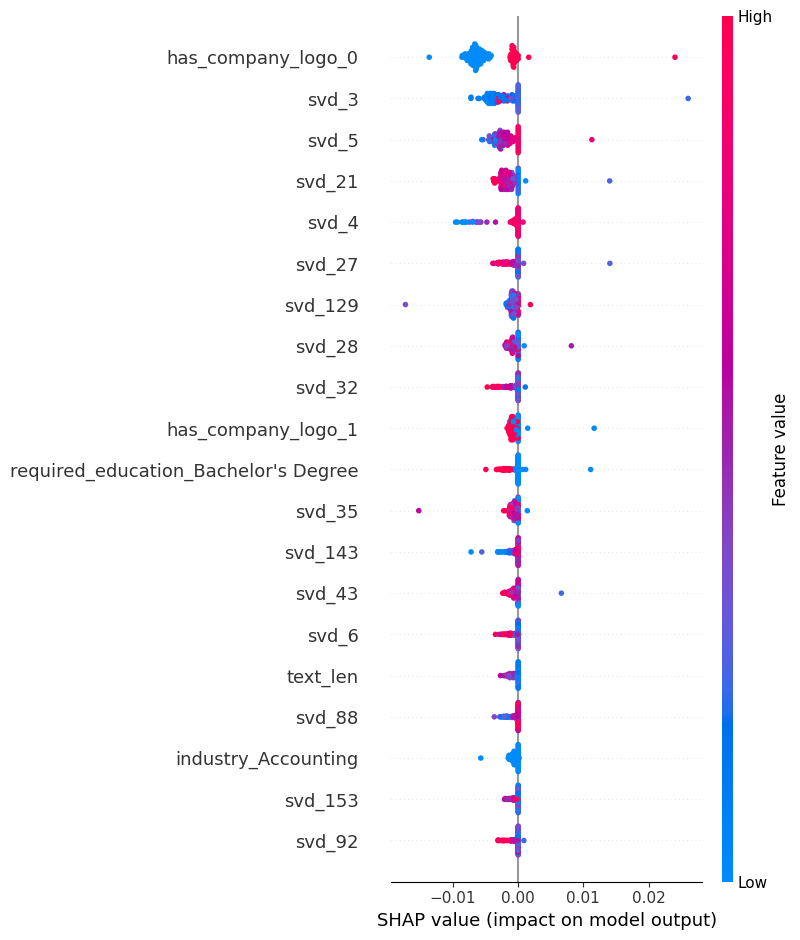

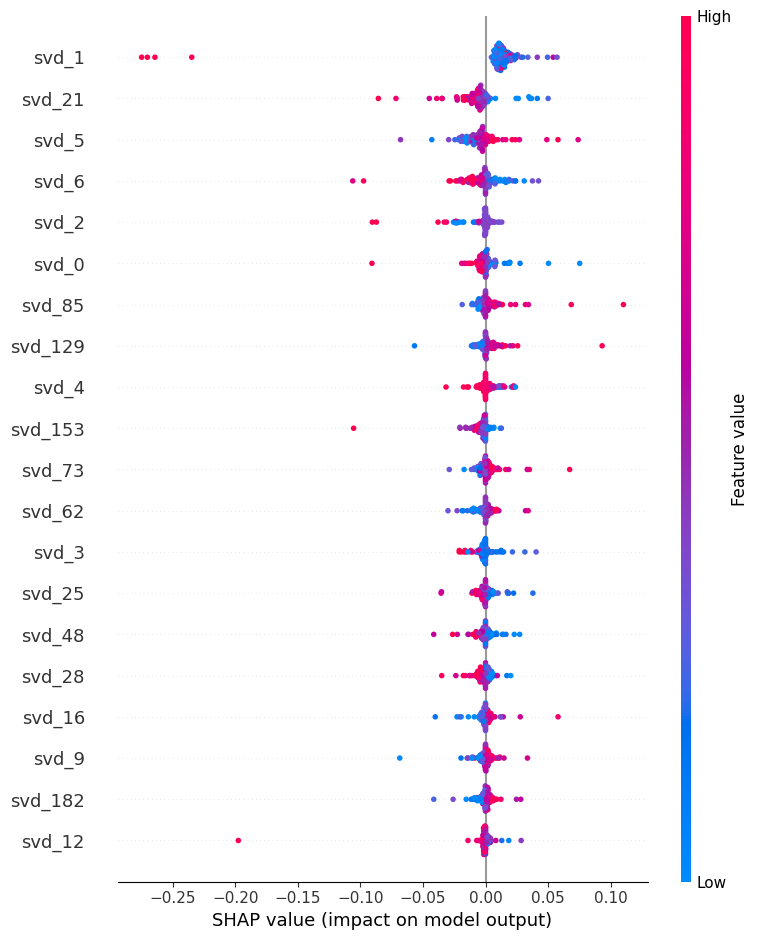

In [43]:
# %%
# 20) SHAP Summary Plots (light, simple)

# LightGBM summary
shap.summary_plot(shap_lgb_values, test_sample, feature_names=feature_names)

# NN summary (SVD only)
shap.summary_plot(shap_nn_values, test_sample_svd, feature_names=[f"svd_{i}" for i in range(test_sample_svd.shape[1])])


In [44]:
# %%
# 21) SHAP ranked feature table for LightGBM
mean_abs_shap_lgb = np.abs(shap_lgb_values).mean(axis=0)

shap_table = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap_lgb
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 SHAP Features (LightGBM):")
display(shap_table.head(20))


Top 20 SHAP Features (LightGBM):


,feature,mean_abs_shap
0,has_company_logo_0,0.005160
1,svd_3,0.002713
2,svd_5,0.002323
3,svd_21,0.001665
4,svd_4,0.001208
5,svd_27,0.000950
6,svd_129,0.000863
7,svd_28,0.000861
8,svd_32,0.000853
9,has_company_logo_1,0.000783


In [46]:
# %%
# FINAL EXPORT CELL – MUST BE RUN before using Streamlit
# This ensures all required model files exist in fraudsense_artifacts/

from pathlib import Path
import shutil
import joblib

ART_DIR = Path("fraudsense_artifacts")
ART_DIR.mkdir(exist_ok=True)

print("Saving all models & preprocessors to:", ART_DIR)

# 1) Save TF-IDF vectorizer
if 'tfidf' in globals():
    joblib.dump(tfidf, ART_DIR / "tfidf_vectorizer.joblib")
    print("Saved tfidf_vectorizer.joblib")

# 2) Save SVD transformer
if 'svd' in globals():
    joblib.dump(svd, ART_DIR / "svd_transformer.joblib")
    print("Saved svd_transformer.joblib")

# 3) Save metadata encoders
if 'ohe' in globals():
    joblib.dump(ohe, ART_DIR / "ohe_meta.joblib")
    print("Saved ohe_meta.joblib")

if 'scaler' in globals():
    joblib.dump(scaler, ART_DIR / "meta_scaler.joblib")
    print("Saved meta_scaler.joblib")

# 4) Save LightGBM model properly for Streamlit
if 'lgbm_model' in globals():
    joblib.dump(lgbm_model, ART_DIR / "lgbm_model.joblib")
    print("Saved lgbm_model.joblib")

# 5) Save NN model
if 'nn' in globals():
    nn.save(str(ART_DIR / "nn_model.keras"))
    print("Saved nn_model.keras")

# 6) Auto-select best model based on PR-AUC
if 'y_prob_nn' in globals() and 'y_prob_lgb' in globals():
    pr_nn = average_precision_score(y_test, y_prob_nn)
    pr_lgb = average_precision_score(y_test, y_prob_lgb)
    best_model = "nn_model.keras" if pr_nn >= pr_lgb else "lgbm_model.joblib"
    with open(ART_DIR / "selected_model.txt", "w") as f:
        f.write(best_model)
    print("Selected best model:", best_model)

print("All artifacts saved successfully!")


Saving all models & preprocessors to: fraudsense_artifacts
Saved tfidf_vectorizer.joblib
Saved svd_transformer.joblib
Saved ohe_meta.joblib
Saved meta_scaler.joblib
Saved lgbm_model.joblib
Saved nn_model.keras
Selected best model: lgbm_model.joblib
All artifacts saved successfully!
